# Feature Engineering and preprocessing

In [1]:
# importing libraries
import pandas as pd
import numpy as np
# loading the raw dataset
df = pd.read_csv('../../data/raw/Fraudtrain.csv')

##### Extract features from trans_date_trans_time

In [2]:
# Convert trans_date_trans_time to pandas datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extract the transaction hour column
df['trans_hour'] = df['trans_date_trans_time'].dt.hour

# Extract the transaction month column
df['trans_month'] = df['trans_date_trans_time'].dt.month 

# Extract the day of the week
df['trans_dayofweek'] = df['trans_date_trans_time'].dt.day_name()

In [3]:
# Verify the new columns
print(df[['trans_date_trans_time', 'trans_hour', 'trans_month', 'trans_dayofweek']].head())

  trans_date_trans_time  trans_hour  trans_month trans_dayofweek
0   2019-01-01 00:00:18           0            1         Tuesday
1   2019-01-01 00:00:44           0            1         Tuesday
2   2019-01-01 00:00:51           0            1         Tuesday
3   2019-01-01 00:01:16           0            1         Tuesday
4   2019-01-01 00:03:06           0            1         Tuesday


In [4]:
df['trans_hour'].unique() # printing the unique values in the extracted series

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [5]:
df['trans_month'].unique() # printing the unique values in the extracted series

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [6]:
df['trans_dayofweek'].unique() # printing the unique values in the extracted series

array(['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday',
       'Monday'], dtype=object)

##### Extract features from unix_time

In [7]:
# Convert unix_time to datetime
df['transaction_time'] = pd.to_datetime(df['unix_time'], unit='s')

# Sort by user (cc_num) and transaction time
df = df.sort_values(by=['cc_num', 'transaction_time'])

# Calculate the previous transaction time using shift
df['unix_time_prev_trans'] = df.groupby(by=['cc_num'])['unix_time'].shift(1)

# Create a new DataFrame with the filled values
df = df.assign(unix_time_prev_trans=df['unix_time_prev_trans'].fillna(df['unix_time'] - 86400))

# Calculate the time delta in minutes between the previous and current transaction
df['timedelta_last_trans'] = (df['unix_time'] - df['unix_time_prev_trans']) // 60
df['timedelta_last_trans'].head()


1017    1440.0
2724    1197.0
2726       2.0
2882     230.0
2907      32.0
Name: timedelta_last_trans, dtype: float64

##### Extract features from dob

In [8]:
# Convert columns to datetime
df['dob'] = pd.to_datetime(df['dob'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Calculate age at the time of transaction
df['cust_age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Display the result
print(df['cust_age'].head())

1017    32
2724    32
2726    32
2882    32
2907    32
Name: cust_age, dtype: int64


##### Extracting features from customer lat/long and merchant lat/long

In [9]:
# Define the Haversine function
def haversine(lat1, lon1, lat2, lon2):
    # Convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lon2])
    
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km

# Create a new DataFrame to perform calculations
df_calc = pd.DataFrame(df)

# Sort by user (cc_num) to ensure correct order of transactions
df_calc = df_calc.sort_values(by=['cc_num'])

# Shift latitude and longitude of the previous merchant to get the previous transaction's coordinates
df_calc['prev_merch_lat'] = df_calc.groupby('cc_num')['merch_lat'].shift(1)
df_calc['prev_merch_long'] = df_calc.groupby('cc_num')['merch_long'].shift(1)

# Fill null values with the current merchant's coordinates using assign method
df_calc = df_calc.assign(
    prev_merch_lat=df_calc['prev_merch_lat'].fillna(df_calc['merch_lat']),
    prev_merch_long=df_calc['prev_merch_long'].fillna(df_calc['merch_long'])
)

# Calculate the distance using the Haversine formula
df_calc['distance_from_prev_merch'] = df_calc.apply(
    lambda row: haversine(row['merch_lat'], row['merch_long'], row['prev_merch_lat'], row['prev_merch_long']), axis=1
)

# Display the first few distances
df_calc['distance_from_prev_merch'].head()

1017      17092.507729
847919    16948.058741
847911    16927.249111
847888    16814.906255
844274    16812.276483
Name: distance_from_prev_merch, dtype: float64

In [10]:
# Add the calculated distances back to the original DataFrame
df['distance_from_prev_merch'] = df_calc['distance_from_prev_merch']
df['distance_from_prev_merch'].head()

1017    17092.507729
2724    16810.034615
2726    16869.192226
2882    16714.557097
2907    16988.374462
Name: distance_from_prev_merch, dtype: float64

In [11]:
list(df.columns)

['Unnamed: 0',
 'trans_date_trans_time',
 'cc_num',
 'merchant',
 'category',
 'amt',
 'first',
 'last',
 'gender',
 'street',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'trans_num',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud',
 'trans_hour',
 'trans_month',
 'trans_dayofweek',
 'transaction_time',
 'unix_time_prev_trans',
 'timedelta_last_trans',
 'cust_age',
 'distance_from_prev_merch']

In [12]:
# Listing the redundant features to be dropped from the df
drop_cols = ['Unnamed: 0','street','merchant','zip','first','last','trans_num','trans_date_trans_time','transaction_time','cc_num','unix_time','unix_time_prev_trans','lat',
              'long','merch_lat','merch_long','dob','city']

In [13]:
df.drop(drop_cols, axis = 1, inplace = True)
df.reset_index(drop=True, inplace = True)
list(df.columns) # remaining list of columns after removing redundant features

['category',
 'amt',
 'gender',
 'state',
 'city_pop',
 'job',
 'is_fraud',
 'trans_hour',
 'trans_month',
 'trans_dayofweek',
 'timedelta_last_trans',
 'cust_age',
 'distance_from_prev_merch']

#### Splitting the train datasets 70% train, 30 % validation

- The aim to do splitting before any econding and normalization is to prevent data leakage from the target into the train
- to avoid over fitting and improve the model's robustness

In [14]:
# splitting the train datasets into X and y
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

# importing splitting module from sklearn
from sklearn.model_selection import train_test_split
# splitting the X and y into train and validate, using stratify split to ensure equal ratio of fraud and genuine 
# between the train and validate as the datasets is highly imbalanced
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size = 0.3, random_state = 42)
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(907672, 12)
(389003, 12)
(907672,)
(389003,)


#### handling outliers and normalisation on train dataset

In [15]:
# installing features enngine
!pip install feature_engine

In [16]:
# Selecting numerical columns
num_cols = X_train.select_dtypes(include = np.number).columns

num_cols

Index(['amt', 'city_pop', 'trans_hour', 'trans_month', 'timedelta_last_trans',
       'cust_age', 'distance_from_prev_merch'],
      dtype='object')

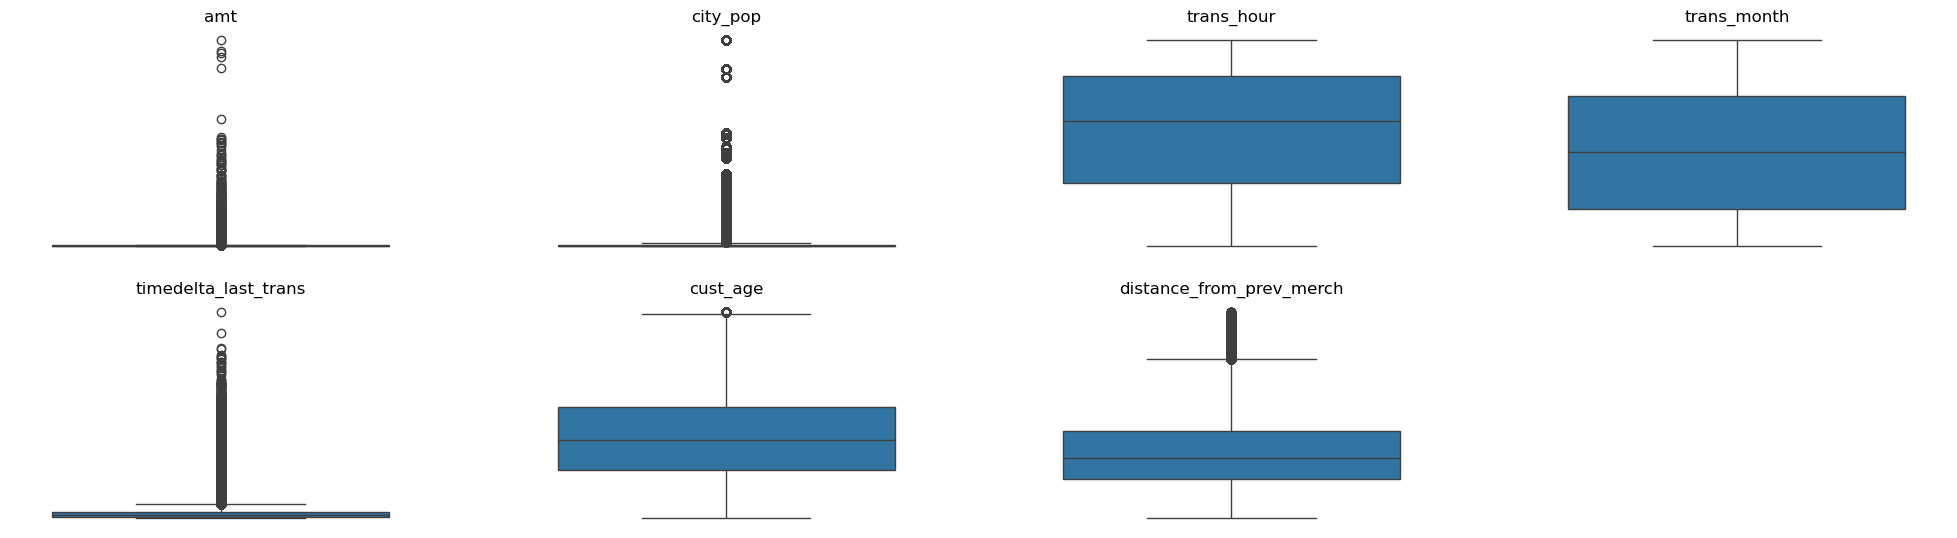

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
# checking for outliers
plt.figure(figsize = [25,10])

for ind,col_name in enumerate(num_cols):
  plot_var = df[col_name]
  plt.subplot(3,4,ind+1)
  sns.boxplot(plot_var)
  plt.title(col_name)
  plt.axis(False)

- amt, city pop, timedelta_lasttrans and distance_from_prev_merch has some outliers

In [18]:
# importing Winsorizer to cap the outlers using IQR
from feature_engine.outliers import Winsorizer
# outliers to be capped
outliers = ['amt', 'city_pop', 'timedelta_last_trans', 'distance_from_prev_merch','cust_age'] 
# choosing the IQR method with fold = 1.5 time of IQR
capper_iqr = Winsorizer(capping_method = 'iqr',tail = 'both', fold = 1.5, variables = outliers) 

In [19]:
print(X_train.shape)
print(X_val.shape)

(907672, 12)
(389003, 12)


In [20]:
# capping outliers in X_train
capper_iqr.fit(X_train)
capper_iqr.fit(X_val)
X_train = capper_iqr.transform(X_train) 
# capping outliers from 
X_test = capper_iqr.transform(X_val)

In [21]:
print(X_train.shape)
print(X_val.shape)

(907672, 12)
(389003, 12)


- None of the data enteries were removed

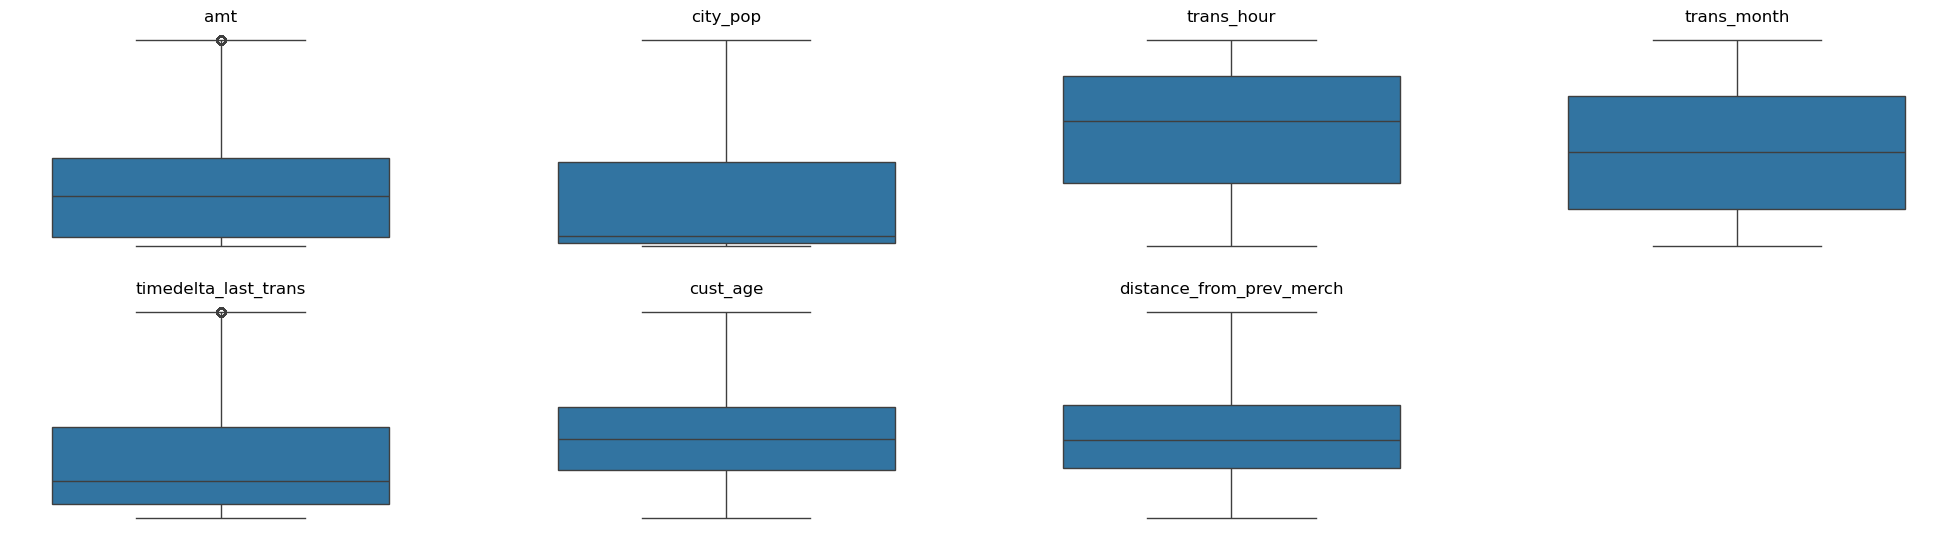

In [22]:
# checking for outliers after capping
plt.figure(figsize = [25,10])

for ind,col_name in enumerate(num_cols):
  plot_var = X_train[col_name]
  plt.subplot(3,4,ind+1)
  sns.boxplot(plot_var)
  plt.title(col_name)
  plt.axis(False)

- outliers have been capped

##### Categorical encoding

In [23]:
# importing categorical encoding
import category_encoders as ce
# importing job lib to save the encoder to be used to encode the unseen data later
import joblib

# Function to apply WOE encoding and save encoders
def apply_woe_and_save_encoders(X_train, X_val, y_train, columns, encoder_filename):
    woe_encoders = []
    for col in columns:
        woe = ce.WOEEncoder(cols=[col])
        
        # Fit the encoder on the training data
        X_train_transformed = woe.fit_transform(X_train[[col]], y_train)
        
        # Transform the validation data
        X_val_transformed = woe.transform(X_val[[col]])
        
        # Add the transformed columns to the original DataFrames
        new_col_name = f"{col}_WOE"
        X_train[new_col_name] = X_train_transformed[col]
        X_val[new_col_name] = X_val_transformed[col]
        
        # Store the encoder
        woe_encoders.append(woe)

    # Save the list of encoders
    joblib.dump(woe_encoders, encoder_filename)
    
    return X_train, X_val

# Categorical columns to encode
columns_to_encode = ['state', 'job', 'category', 'trans_dayofweek']

# Apply WOE encoding to training and validation data and save encoders
encoder_filename = 'woe_encoders_new.joblib'
X_train_encoded, X_val_encoded = apply_woe_and_save_encoders(X_train, X_val, y_train, columns_to_encode, encoder_filename)

In [24]:
#importing one hot encoding
from sklearn.preprocessing import OneHotEncoder
# creating one hot encoded function
def apply_one_hot_encoding(X_train, X_val, column):
    ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' to avoid dummy variable trap
    
    # Fit the encoder on the training data
    ohe.fit(X_train[[column]])
    
    # Transform both training and validation data
    X_train_ohe = ohe.transform(X_train[[column]])
    X_val_ohe = ohe.transform(X_val[[column]])
    
    # Get new column names for the one-hot encoded columns
    ohe_columns = ohe.get_feature_names_out([column])
    
    # Create DataFrames from the one-hot encoded arrays
    X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_columns, index=X_train.index)
    X_val_ohe_df = pd.DataFrame(X_val_ohe, columns=ohe_columns, index=X_val.index)
    
    # Concatenate the new one-hot encoded columns to the original DataFrames
    X_train = pd.concat([X_train, X_train_ohe_df], axis=1)
    X_val = pd.concat([X_val, X_val_ohe_df], axis=1)
    
    return X_train, X_val

# Gender column to be encoded
ohe_column = 'gender'

# Apply one-hot encoding to the gender column in the WOE-encoded DataFrames
X_train_encoded, X_val_encoded = apply_one_hot_encoding(X_train_encoded, X_val_encoded, ohe_column)

##### Normalizing the data using MinMaxscaler

In [25]:
# Columns to drop
columns_to_drop = ['category', 'gender', 'state', 'job', 'trans_dayofweek']

# Drop the specified columns from the training and validation sets
X_train_encoded = X_train_encoded.drop(columns=columns_to_drop)
X_val_encoded = X_val_encoded.drop(columns=columns_to_drop)

In [26]:
# Importing MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data
X_train_scaled = scaler.fit_transform(X_train_encoded)

# Transform the validation data
X_val_scaled = scaler.transform(X_val_encoded)

# Convert the transformed data back to DataFrames
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns, index=X_train_encoded.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X_val_encoded.columns, index=X_val_encoded.index)


print(X_train_scaled_df.head())
print(X_val_scaled_df.head())

             amt  city_pop  trans_hour  trans_month  timedelta_last_trans  \
191915  0.345657  0.047743    0.391304     0.454545              0.335400   
318435  0.055513  1.000000    0.565217     0.000000              0.572920   
212041  0.026249  0.012681    0.608696     0.090909              0.255791   
979109  0.182132  0.003241    0.608696     0.454545              0.632953   
614053  0.023130  0.383052    0.913043     1.000000              0.095269   

        cust_age  distance_from_prev_merch  state_WOE   job_WOE  category_WOE  \
191915  0.147239                  0.450749   0.134523  0.265507      0.471296   
318435  0.417178                  0.268176   0.145714  0.304951      0.169627   
212041  0.478528                  0.324890   0.145714  0.312038      0.019611   
979109  0.736196                  0.274984   0.145714  0.178402      0.000000   
614053  0.368098                  0.212649   0.155150  0.310707      0.250640   

        trans_dayofweek_WOE  gender_M  
191915    

# Unseen test Data preprocessing

In [27]:
# Load the unseen dataset
df = pd.read_csv('../../data/raw/Fraudtest.csv')

# Preprocessing the unseen data
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df['trans_month'] = df['trans_date_trans_time'].dt.month
df['trans_dayofweek'] = df['trans_date_trans_time'].dt.day_name()

df['transaction_time'] = pd.to_datetime(df['unix_time'], unit='s')
df = df.sort_values(by=['cc_num', 'transaction_time'])

df['unix_time_prev_trans'] = df.groupby(by=['cc_num'])['unix_time'].shift(1)
df = df.assign(unix_time_prev_trans=df['unix_time_prev_trans'].fillna(df['unix_time'] - 86400))
df['timedelta_last_trans'] = (df['unix_time'] - df['unix_time_prev_trans']) // 60

df['dob'] = pd.to_datetime(df['dob'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['cust_age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Define the Haversine function
def haversine(lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km

df_calc = pd.DataFrame(df)
df_calc = df_calc.sort_values(by=['cc_num'])
df_calc['prev_merch_lat'] = df_calc.groupby('cc_num')['merch_lat'].shift(1)
df_calc['prev_merch_long'] = df_calc.groupby('cc_num')['merch_long'].shift(1)
df_calc = df_calc.assign(
    prev_merch_lat=df_calc['prev_merch_lat'].fillna(df_calc['merch_lat']),
    prev_merch_long=df_calc['prev_merch_long'].fillna(df_calc['merch_long'])
)
df_calc['distance_from_prev_merch'] = df_calc.apply(
    lambda row: haversine(row['merch_lat'], row['merch_long'], row['prev_merch_lat'], row['prev_merch_long']), axis=1
)
df['distance_from_prev_merch'] = df_calc['distance_from_prev_merch']

# Drop redundant columns
drop_cols = ['Unnamed: 0','street','merchant','zip','first','last','trans_num','trans_date_trans_time','transaction_time','cc_num','unix_time','unix_time_prev_trans','lat',
              'long','merch_lat','merch_long','dob','city']
df.drop(drop_cols, axis=1, inplace=True)
df.reset_index(drop=True, inplace=True)

# Separate features and target variable
X_unseen = df.drop(columns=["is_fraud"])
y_unseen = df["is_fraud"]

# Apply outlier capping
outliers = ['amt', 'city_pop', 'timedelta_last_trans', 'distance_from_prev_merch', 'cust_age']
capper_iqr = Winsorizer(capping_method='iqr', tail='both', fold=1.5, variables=outliers)
capper_iqr.fit(X_unseen)
X_unseen = capper_iqr.transform(X_unseen)

# Load the saved WOE encoders
woe_encoders = joblib.load('woe_encoders_new.joblib')

# Apply WOE Encoding
def apply_woe(X, woe_columns, woe_encoders):
    for col, encoder in zip(woe_columns, woe_encoders):
        X_transformed = encoder.transform(X[[col]])
        new_col_name = f"{col}_WOE"
        X[new_col_name] = X_transformed[col]
    return X

woe_columns = ['state', 'job', 'category', 'trans_dayofweek']
X_unseen = apply_woe(X_unseen, woe_columns, woe_encoders)

# Apply One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe.fit(X_unseen[['gender']])  # Fit on the training data

X_unseen_ohe = ohe.transform(X_unseen[['gender']])
ohe_columns = ohe.get_feature_names_out(['gender'])
X_unseen_ohe_df = pd.DataFrame(X_unseen_ohe, columns=ohe_columns, index=X_unseen.index)
X_unseen = pd.concat([X_unseen, X_unseen_ohe_df], axis=1)
X_unseen.drop(columns=['gender'], inplace=True)

# Drop redundant columns
columns_to_drop = ['category', 'state', 'job', 'trans_dayofweek']
X_unseen.drop(columns=columns_to_drop, inplace=True)

# Apply MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train_encoded)  # Fit on the training data

X_unseen_scaled = scaler.transform(X_unseen)
X_unseen_scaled_df = pd.DataFrame(X_unseen_scaled, columns=X_unseen.columns, index=X_unseen.index)

In [28]:
print(X_unseen_scaled_df.head())

        amt  city_pop  trans_hour  trans_month  timedelta_last_trans  \
0  0.642765  0.032647    0.565217     0.454545              0.831321   
1  0.402937  0.032647    0.695652     0.454545              0.129853   
2  0.333961  0.032647    0.304348     0.454545              0.608157   
3  0.450861  0.032647    0.652174     0.454545              0.295595   
4  0.764187  0.032647    0.521739     0.454545              0.819576   

   cust_age  distance_from_prev_merch  state_WOE   job_WOE  category_WOE  \
0  0.257669                  0.841275   0.148779  0.347469      0.022581   
1  0.257669                  0.817953   0.148779  0.347469      0.270028   
2  0.257669                  0.861393   0.148779  0.347469      0.471296   
3  0.257669                  0.847543   0.148779  0.347469      0.126064   
4  0.257669                  0.843158   0.148779  0.347469      0.169627   

   trans_dayofweek_WOE  gender_M  
0             0.028068       0.0  
1             0.028068       0.0  
2    

# Adding new Features

#### Creating Interaction Features

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
import numpy as np

# Load the raw datasets
Raw_df = pd.read_csv('../../data/raw/Fraudtrain.csv')
Raw_df['trans_date_trans_time'] = pd.to_datetime(Raw_df['trans_date_trans_time'])

# Splitting the raw datasets into X and y
X_raw = Raw_df.drop(columns=["is_fraud"])
y_raw = Raw_df["is_fraud"]

# Splitting X and y into train and validate sets using stratify split
X_train_1, X_val_1, y_train_1, y_val_1 = train_test_split(X_raw, y_raw, stratify=y_raw, test_size=0.3, random_state=42)

# Load the unseen dataset
Unseen_df = pd.read_csv('../../data/raw/Fraudtest.csv')
Unseen_df['trans_date_trans_time'] = pd.to_datetime(Unseen_df['trans_date_trans_time'])

# Preprocess the Raw Data
def preprocess_data(df):
    df['trans_hour'] = df['trans_date_trans_time'].dt.hour
    df['trans_month'] = df['trans_date_trans_time'].dt.month
    df['trans_dayofweek'] = df['trans_date_trans_time'].dt.day_name()
    
    df['transaction_time'] = pd.to_datetime(df['unix_time'], unit='s')
    df = df.sort_values(by=['cc_num', 'transaction_time'])
    
    df['unix_time_prev_trans'] = df.groupby(by=['cc_num'])['unix_time'].shift(1)
    df['unix_time_prev_trans'] = df['unix_time_prev_trans'].fillna(df['unix_time'] - 86400)
    df['timedelta_last_trans'] = (df['unix_time'] - df['unix_time_prev_trans']) // 60
    
    df['dob'] = pd.to_datetime(df['dob'])
    df['cust_age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

    return df

X_train_1 = preprocess_data(X_train_1)
X_val_1 = preprocess_data(X_val_1)
Unseen_df = preprocess_data(Unseen_df)

# Transaction frequency
X_train_1['trans_frequency'] = X_train_1.groupby('cc_num')['trans_date_trans_time'].transform('count')
X_val_1['trans_frequency'] = X_val_1.groupby('cc_num')['trans_date_trans_time'].transform('count')
Unseen_df['trans_frequency'] = Unseen_df.groupby('cc_num')['trans_date_trans_time'].transform('count')

# Average transaction amount by category
X_train_1['avg_amt_category'] = X_train_1.groupby('category')['amt'].transform('mean')
X_val_1['avg_amt_category'] = X_val_1.groupby('category')['amt'].transform('mean')
Unseen_df['avg_amt_category'] = Unseen_df.groupby('category')['amt'].transform('mean')

# Assuming X_train_scaled_df, X_val_scaled_df, and X_unseen_scaled_df are your already processed and scaled DataFrames
# Add the domain-specific features to the scaled DataFrames
X_train_scaled_df['trans_frequency'] = X_train_1['trans_frequency']
X_val_scaled_df['trans_frequency'] = X_val_1['trans_frequency']
X_unseen_scaled_df['trans_frequency'] = Unseen_df['trans_frequency']

X_train_scaled_df['avg_amt_category'] = X_train_1['avg_amt_category']
X_val_scaled_df['avg_amt_category'] = X_val_1['avg_amt_category']
X_unseen_scaled_df['avg_amt_category'] = Unseen_df['avg_amt_category']

# Create polynomial features, but exclude the already existing interaction features to avoid redundancy
features_to_exclude = ['amt_age_interaction', 'amt_distance_interaction']
X_train_scaled_df_no_interactions = X_train_scaled_df.drop(columns=features_to_exclude, errors='ignore')
X_val_scaled_df_no_interactions = X_val_scaled_df.drop(columns=features_to_exclude, errors='ignore')
X_unseen_scaled_df_no_interactions = X_unseen_scaled_df.drop(columns=features_to_exclude, errors='ignore')

# Impute missing values
imputer = SimpleImputer(strategy='mean')

X_train_scaled_df_no_interactions = imputer.fit_transform(X_train_scaled_df_no_interactions)
X_val_scaled_df_no_interactions = imputer.transform(X_val_scaled_df_no_interactions)
X_unseen_scaled_df_no_interactions = imputer.transform(X_unseen_scaled_df_no_interactions)

poly = PolynomialFeatures(degree=2, include_bias=False)

# Fit and transform the training data without interaction features
X_train_poly = poly.fit_transform(X_train_scaled_df_no_interactions)
X_val_poly = poly.transform(X_val_scaled_df_no_interactions)
X_unseen_poly = poly.transform(X_unseen_scaled_df_no_interactions)

# Get the feature names
poly_feature_names = poly.get_feature_names_out(imputer.feature_names_in_)

# Create DataFrames for the polynomial features
X_train_poly_df = pd.DataFrame(X_train_poly, columns=poly_feature_names)
X_val_poly_df = pd.DataFrame(X_val_poly, columns=poly_feature_names)
X_unseen_poly_df = pd.DataFrame(X_unseen_poly, columns=poly_feature_names)

# Combine the original scaled DataFrame with polynomial features and domain-specific features
X_train_combined = pd.concat([X_train_scaled_df.reset_index(drop=True), X_train_poly_df], axis=1)
X_val_combined = pd.concat([X_val_scaled_df.reset_index(drop=True), X_val_poly_df], axis=1)
X_unseen_combined = pd.concat([X_unseen_scaled_df.reset_index(drop=True), X_unseen_poly_df], axis=1)

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the combined training data
X_train_final = scaler.fit_transform(X_train_combined)

# Transform the validation and unseen data
X_val_final = scaler.transform(X_val_combined)
X_unseen_final = scaler.transform(X_unseen_combined)

# Convert the transformed data back to DataFrames
X_train_final_df = pd.DataFrame(X_train_final, columns=X_train_combined.columns)
X_val_final_df = pd.DataFrame(X_val_final, columns=X_val_combined.columns)
X_unseen_final_df = pd.DataFrame(X_unseen_final, columns=X_unseen_combined.columns)

In [30]:
# Display a sample of the final DataFrames
print("Final Training DataFrame Sample:")
print(X_train_final_df.head())

Final Training DataFrame Sample:
        amt  city_pop  trans_hour  trans_month  timedelta_last_trans  \
0  0.345657  0.047743    0.391304     0.454545              0.335400   
1  0.055513  1.000000    0.565217     0.000000              0.572920   
2  0.026249  0.012681    0.608696     0.090909              0.255791   
3  0.182132  0.003241    0.608696     0.454545              0.632953   
4  0.023130  0.383052    0.913043     1.000000              0.095269   

   cust_age  distance_from_prev_merch  state_WOE   job_WOE  category_WOE  ...  \
0  0.147239                  0.450749   0.134523  0.265507      0.471296  ...   
1  0.417178                  0.268176   0.145714  0.304951      0.169627  ...   
2  0.478528                  0.324890   0.145714  0.312038      0.019611  ...   
3  0.736196                  0.274984   0.145714  0.178402      0.000000  ...   
4  0.368098                  0.212649   0.155150  0.310707      0.250640  ...   

   trans_dayofweek_WOE^2  trans_dayofweek_WOE g

In [31]:
print("\nFinal Validation DataFrame Sample:")
print(X_val_final_df.head())


Final Validation DataFrame Sample:
        amt  city_pop  trans_hour  trans_month  timedelta_last_trans  \
0  0.058892  0.000282    0.869565     0.181818              0.326917   
1  0.032850  0.057344    0.913043     0.636364              0.075693   
2  0.002131  0.047361    0.913043     0.454545              0.050897   
3  0.238113  0.031158    0.652174     0.454545              1.078630   
4  0.546293  0.033432    0.521739     0.909091              0.105057   

   cust_age  distance_from_prev_merch  state_WOE   job_WOE  category_WOE  ...  \
0  0.588957                  0.374344   0.122630  0.274701      0.022581  ...   
1  0.220859                  0.717075   0.081477  0.246744      0.022581  ...   
2  0.417178                  0.182525   0.000000  0.099430      0.169627  ...   
3  0.294479                  0.528490   0.134523  0.246744      0.126064  ...   
4  0.147239                  0.262418   0.165364  0.246042      0.000000  ...   

   trans_dayofweek_WOE^2  trans_dayofweek_WO

In [32]:
print("\nFinal Unseen DataFrame Sample:")
print(X_unseen_final_df.head())


Final Unseen DataFrame Sample:
        amt  city_pop  trans_hour  trans_month  timedelta_last_trans  \
0  0.642765  0.032647    0.565217     0.454545              0.831321   
1  0.402937  0.032647    0.695652     0.454545              0.129853   
2  0.333961  0.032647    0.304348     0.454545              0.608157   
3  0.450861  0.032647    0.652174     0.454545              0.295595   
4  0.764187  0.032647    0.521739     0.454545              0.819576   

   cust_age  distance_from_prev_merch  state_WOE   job_WOE  category_WOE  ...  \
0  0.257669                  0.841275   0.148779  0.347469      0.022581  ...   
1  0.257669                  0.817953   0.148779  0.347469      0.270028  ...   
2  0.257669                  0.861393   0.148779  0.347469      0.471296  ...   
3  0.257669                  0.847543   0.148779  0.347469      0.126064  ...   
4  0.257669                  0.843158   0.148779  0.347469      0.169627  ...   

   trans_dayofweek_WOE^2  trans_dayofweek_WOE ge

In [34]:
%%time
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
# Apply Recursive Feature Elimination (RFE)
rfe = RFE(estimator=RandomForestClassifier(), n_features_to_select=20)
X_train_rfe = rfe.fit_transform(X_train_final_df, y_train_1)
X_val_rfe = rfe.transform(X_val_final_df)
X_unseen_rfe = rfe.transform(X_unseen_final_df)

# Get the selected feature names
selected_features = X_train_final_df.columns[rfe.get_support()]

# Convert the transformed data back to DataFrames
X_train_rfe_df = pd.DataFrame(X_train_rfe, columns=selected_features)
X_val_rfe_df = pd.DataFrame(X_val_rfe, columns=selected_features)
X_unseen_rfe_df = pd.DataFrame(X_unseen_rfe, columns=selected_features)

# Display a sample of the final DataFrames after RFE
print("Final Training DataFrame Sample after RFE:")
print(X_train_rfe_df.head())

print("\nFinal Validation DataFrame Sample after RFE:")
print(X_val_rfe_df.head())

print("\nFinal Unseen DataFrame Sample after RFE:")
print(X_unseen_rfe_df.head())

Final Training DataFrame Sample after RFE:
   timedelta_last_trans  cust_age  category_WOE  timedelta_last_trans  \
0              0.335400  0.147239      0.471296              0.335400   
1              0.572920  0.417178      0.169627              0.572920   
2              0.255791  0.478528      0.019611              0.255791   
3              0.632953  0.736196      0.000000              0.632953   
4              0.095269  0.368098      0.250640              0.095269   

   category_WOE     amt^2  amt trans_hour  amt cust_age  amt job_WOE  \
0      0.471296  0.119478        0.135257      0.050894     0.091774   
1      0.169627  0.003082        0.031377      0.023159     0.016929   
2      0.019611  0.000689        0.015978      0.012561     0.008191   
3      0.000000  0.033172        0.110863      0.134085     0.032493   
4      0.250640  0.000535        0.021119      0.008514     0.007187   

   amt category_WOE  city_pop distance_from_prev_merch  trans_hour cust_age  \
0     

In [35]:
X_unseen_rfe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   timedelta_last_trans               555719 non-null  float64
 1   cust_age                           555719 non-null  float64
 2   category_WOE                       555719 non-null  float64
 3   timedelta_last_trans               555719 non-null  float64
 4   category_WOE                       555719 non-null  float64
 5   amt^2                              555719 non-null  float64
 6   amt trans_hour                     555719 non-null  float64
 7   amt cust_age                       555719 non-null  float64
 8   amt job_WOE                        555719 non-null  float64
 9   amt category_WOE                   555719 non-null  float64
 10  city_pop distance_from_prev_merch  555719 non-null  float64
 11  trans_hour cust_age                5557

In [39]:
print(X_train_rfe_df.dtypes)


timedelta_last_trans                 float64
cust_age                             float64
category_WOE                         float64
timedelta_last_trans                 float64
category_WOE                         float64
amt^2                                float64
amt trans_hour                       float64
amt cust_age                         float64
amt job_WOE                          float64
amt category_WOE                     float64
city_pop distance_from_prev_merch    float64
trans_hour cust_age                  float64
trans_hour job_WOE                   float64
trans_hour category_WOE              float64
cust_age^2                           float64
cust_age job_WOE                     float64
cust_age category_WOE                float64
job_WOE category_WOE                 float64
category_WOE^2                       float64
category_WOE gender_M                float64
dtype: object


In [44]:
print(X_train_rfe_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907672 entries, 0 to 907671
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   timedelta_last_trans_0             907672 non-null  float64
 1   cust_age                           907672 non-null  float64
 2   category_WOE_2                     907672 non-null  float64
 3   timedelta_last_trans_3             907672 non-null  float64
 4   category_WOE_4                     907672 non-null  float64
 5   amt^2                              907672 non-null  float64
 6   amt trans_hour                     907672 non-null  float64
 7   amt cust_age                       907672 non-null  float64
 8   amt job_WOE                        907672 non-null  float64
 9   amt category_WOE                   907672 non-null  float64
 10  city_pop distance_from_prev_merch  907672 non-null  float64
 11  trans_hour cust_age                9076

Scale Pos Weight: 13.105658297322067
Estimate for scale_pos_weight: 13.106
Validation Accuracy: 0.9883445628954018
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99    386751
           1       0.32      0.88      0.47      2252

    accuracy                           0.99    389003
   macro avg       0.66      0.94      0.73    389003
weighted avg       1.00      0.99      0.99    389003

Validation Confusion Matrix:
 [[382477   4274]
 [   260   1992]]
Validation ROC AUC Score: 0.9948501053406097
Validation PR AUC Score: 0.722385109424025


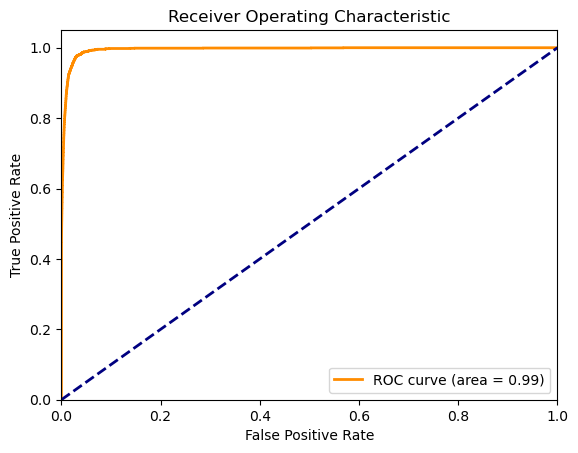

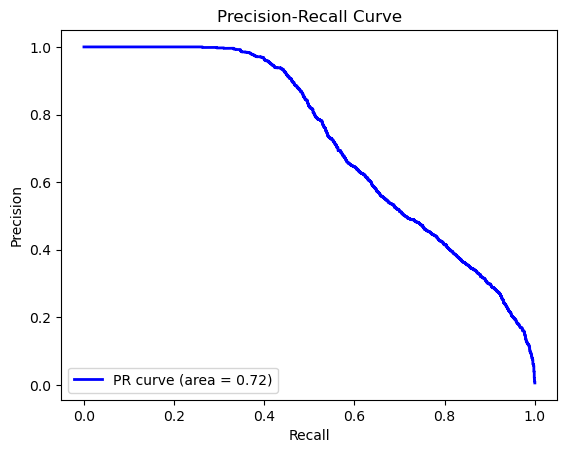

In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from collections import Counter
import numpy as np

# Function to ensure unique column names
def ensure_unique_column_names(df):
    df.columns = [f'{col}_{i}' if df.columns.tolist().count(col) > 1 else col for i, col in enumerate(df.columns)]
    return df

# Apply the function to the DataFrames
X_train_rfe_df = ensure_unique_column_names(X_train_rfe_df)
X_val_rfe_df = ensure_unique_column_names(X_val_rfe_df)
X_unseen_rfe_df = ensure_unique_column_names(X_unseen_rfe_df)

# Convert DataFrames to Numpy arrays
X_train_rfe_np = X_train_rfe_df.to_numpy()
X_val_rfe_np = X_val_rfe_df.to_numpy()
X_unseen_rfe_np = X_unseen_rfe_df.to_numpy()

# Calculate scale_pos_weight using the square root of the ratio
counter = Counter(y_train)
scale_pos_weight = np.sqrt(counter[0] / counter[1])

print("Scale Pos Weight:", scale_pos_weight)
print('Estimate for scale_pos_weight: %.3f' % scale_pos_weight)

# Define the initial XGBoost model
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)

# Train the model on the training data
xgb_model.fit(X_train_rfe_np, y_train)

# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_rfe_np)
y_val_pred_proba = xgb_model.predict_proba(X_val_rfe_np)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

# If you want to make predictions on the unseen data
y_unseen_pred = xgb_model.predict(X_unseen_rfe_np)
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_rfe_np)[:, 1]

# Optionally, evaluate on unseen data (if labels are available)
# For example:
# print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
# print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))


Unseen Data Accuracy: 0.9964730376323285
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.55      0.46      0.50      2145

    accuracy                           1.00    555719
   macro avg       0.77      0.73      0.75    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix:
 [[552778    796]
 [  1164    981]]
Unseen Data ROC AUC Score: 0.9636351378656834
Unseen Data PR AUC Score: 0.5105358286583924


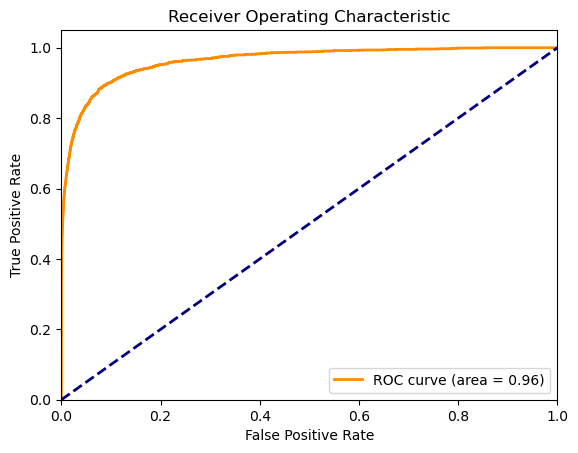

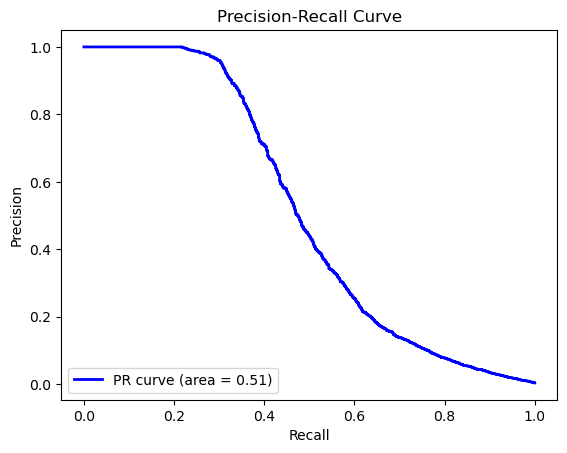

In [43]:
# Make predictions on the unseen data with the base model
y_unseen_pred = xgb_model.predict(X_unseen_rfe_df)
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_rfe_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()